In [6]:
# ==========================================================
# FreshGrade AI – Improved Training Pipeline (MobileNetV2)
# ==========================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
from tqdm import tqdm


In [7]:

# =============================
# Paths
# =============================
train_dir = "D:/PDD_new_projrct/dataset/Train"  # Change if needed
save_path = "freshgrade_new.pt"


In [8]:

# =============================
# Data Augmentation
# =============================
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


In [9]:

# =============================
# Dataset & Dataloaders
# =============================
dataset = datasets.ImageFolder(train_dir, transform=transform_train)
num_classes = len(dataset.classes)
print(f"✅ Classes: {dataset.classes}")
print(f"✅ Number of classes: {num_classes}")

# Train/Val Split
train_size = int(0.7 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

# Weighted Sampling (fix imbalance)
labels_all = [s[1] for s in dataset.samples]
class_counts = np.array([labels_all.count(i) for i in range(num_classes)])
class_weights = 1. / (class_counts + 1e-6)
sample_weights = np.array([class_weights[label] for label in labels_all])

train_indices = train_dataset.indices
train_sample_weights = [sample_weights[i] for i in train_indices]
train_sampler = WeightedRandomSampler(train_sample_weights, num_samples=len(train_sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=train_sampler, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

# Save class indices mapping
with open("class_indices.json", "w") as f:
    json.dump(dataset.class_to_idx, f)
print(dataset.class_to_idx)

# =============================
# Model Setup (MobileNetV2)
# =============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using device: {device}")

model = models.mobilenet_v2(weights="IMAGENET1K_V1")

# Freeze all feature extractor layers initially
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier layer
model.classifier[1] = nn.Linear(model.last_channel, num_classes)
model = model.to(device)


✅ Classes: ['freshapples', 'freshbanana', 'freshbittergroud', 'freshcapsicum', 'freshcucumber', 'freshokra', 'freshoranges', 'freshpotato', 'freshtomato', 'rottenapples', 'rottenbanana', 'rottenbittergroud', 'rottencapsicum', 'rottencucumber', 'rottenokra', 'rottenoranges', 'rottenpotato', 'rottentomato']
✅ Number of classes: 18
{'freshapples': 0, 'freshbanana': 1, 'freshbittergroud': 2, 'freshcapsicum': 3, 'freshcucumber': 4, 'freshokra': 5, 'freshoranges': 6, 'freshpotato': 7, 'freshtomato': 8, 'rottenapples': 9, 'rottenbanana': 10, 'rottenbittergroud': 11, 'rottencapsicum': 12, 'rottencucumber': 13, 'rottenokra': 14, 'rottenoranges': 15, 'rottenpotato': 16, 'rottentomato': 17}
🚀 Using device: cpu


In [10]:

# =============================
# Training Config
# =============================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

epochs = 10
warmup_epochs = 5  # after these, unfreeze backbone
best_acc = 0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []


In [11]:

# =============================
# Training Loop
# =============================
for epoch in range(epochs):
    print(f"\nEpoch [{epoch+1}/{epochs}]")
    model.train()
    running_loss, correct, total = 0, 0, 0

    for inputs, labels in tqdm(train_loader, desc="Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    train_loss = running_loss / len(train_loader)



Epoch [1/10]



Epoch [2/10]



Epoch [3/10]



Epoch [4/10]



Epoch [5/10]



Epoch [6/10]



Epoch [7/10]



Epoch [8/10]



Epoch [9/10]



Epoch [10/10]


In [12]:

    # =============================
    # Validation
    # =============================
    model.eval()
    val_preds, val_labels = [], []
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds) * 100
    val_loss = val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    scheduler.step(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Unfreeze after warmup
    if epoch + 1 == warmup_epochs:
        print("🔓 Unfreezing all layers for fine-tuning...")
        for param in model.features.parameters():
            param.requires_grad = True
        optimizer = optim.Adam(model.parameters(), lr=1e-4)

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), save_path)
        print(f"💾 Model saved! Best Accuracy: {best_acc:.2f}%")


Train Loss: 0.1939 | Train Acc: 93.22% | Val Loss: 0.1489 | Val Acc: 94.69%
💾 Model saved! Best Accuracy: 94.69%



📊 Final Validation Report:
                   precision    recall  f1-score   support

      freshapples       0.98      0.98      0.98       281
      freshbanana       1.00      1.00      1.00       302
 freshbittergroud       0.99      1.00      1.00       109
    freshcapsicum       0.98      1.00      0.99       275
    freshcucumber       0.93      0.81      0.87       156
        freshokra       0.84      0.93      0.88       199
     freshoranges       0.90      0.99      0.94       295
      freshpotato       0.86      0.93      0.90       143
      freshtomato       0.99      0.98      0.98       326
     rottenapples       0.91      0.99      0.95       322
     rottenbanana       0.99      1.00      1.00       312
rottenbittergroud       1.00      1.00      1.00       118
   rottencapsicum       1.00      0.97      0.98       281
   rottencucumber       0.73      0.90      0.80       118
       rottenokra       0.84      0.66      0.74        98
    rottenoranges       1.0

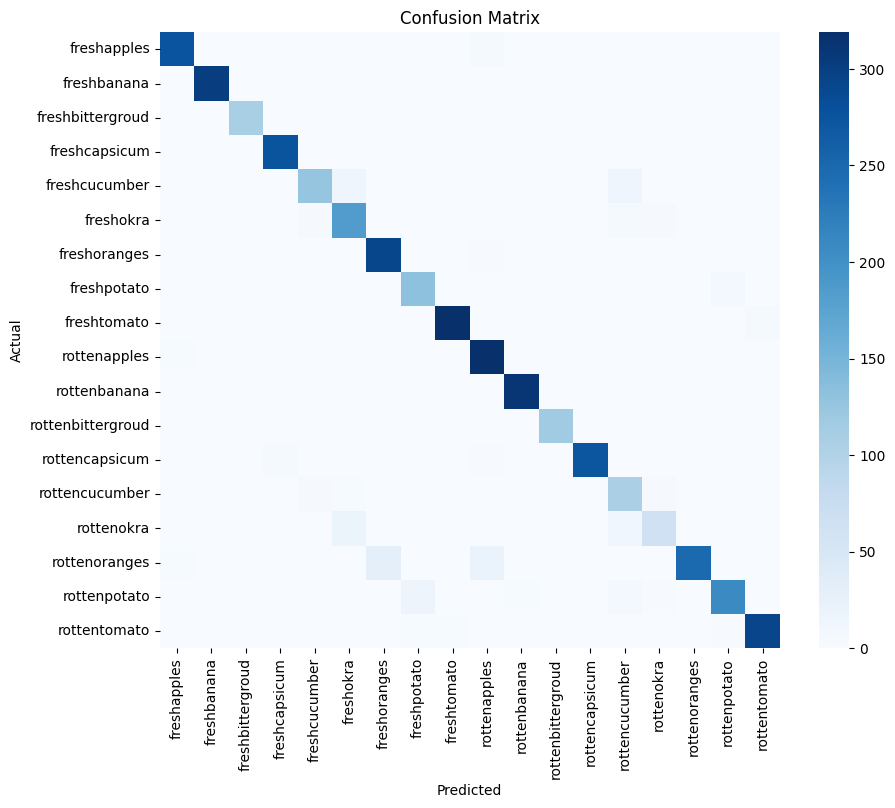

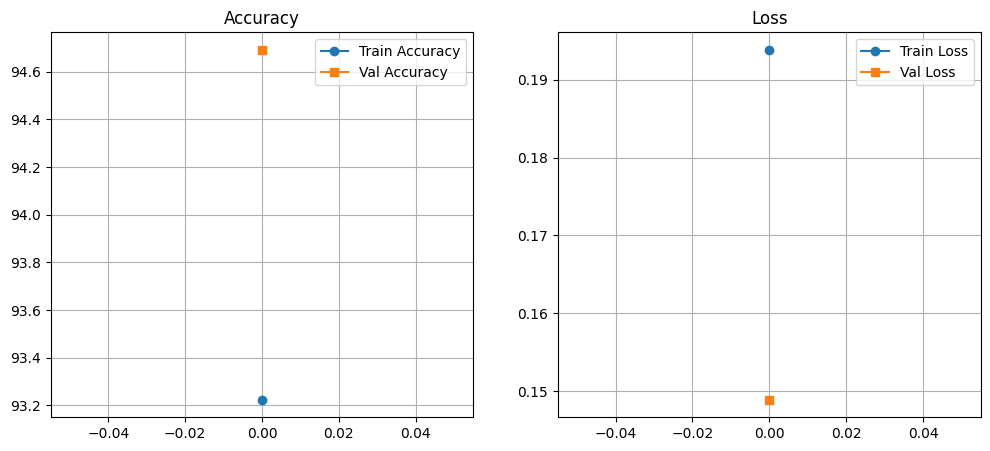

In [13]:

# =============================
# Confusion Matrix + Plots
# =============================
print("\n📊 Final Validation Report:")
print(classification_report(val_labels, val_preds, target_names=dataset.classes))

cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=dataset.classes, yticklabels=dataset.classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Accuracy & Loss Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label="Train Accuracy", marker="o")
plt.plot(val_accuracies, label="Val Accuracy", marker="s")
plt.legend(); plt.grid(True); plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses, label="Val Loss", marker="s")
plt.legend(); plt.grid(True); plt.title("Loss")
plt.show()
